# SMS SPAM DEEP LEARNING
Etudiant : Amaury TISSOT

Classe : [DIS] MIA 26.2

## Dépendances

In [1]:
# Installation des dépendances du projet listées dans requirements.txt
!pip install -r ../requirements.txt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Choix du dataset
Etant un véritable novice en matière de deeplearning, j'ai choisi le dataset suivant : [SMS Spam Collection — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) qui me semble approprié pour découvrir le concept de RNN.

## Importation du dataset

In [3]:
import io
import os
import zipfile
import urllib.request

DATA_DIR = "../data"
CSV_PATH = os.path.join(DATA_DIR, "sms_spam.csv")
URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# Téléchargement + extraction au premier lancement, puis lecture du cache local ensuite
if not os.path.exists(CSV_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    raw = urllib.request.urlopen(URL, timeout=60).read()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])
    df.to_csv(CSV_PATH, index=False)
else:
    df = pd.read_csv(CSV_PATH)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Exploration des données (EDA)

### 1. Aperçu général

In [4]:
print("Dimensions (lignes, colonnes) :", df.shape)
df.info()

Dimensions (lignes, colonnes) : (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### 2. Valeurs manquantes et doublons

In [5]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nNombre de lignes en double :", df.duplicated().sum())

Valeurs manquantes par colonne :
label      0
message    0
dtype: int64

Nombre de lignes en double : 403


On supprime les doublons pour ne garder qu'un exemplaire de chaque message. `reset_index(drop=True)` renumérote les lignes proprement après suppression.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("Nouvelles dimensions du dataframe après suppression des doublons :", df.shape)

Nouvelles dimensions du dataframe après suppression des doublons : (5169, 2)


### 3. Répartition des classes (équilibre)

On regarde combien de "ham" ( messages légitimes) et de "spam" le data set contient.

- `value_counts()` compte les occurrences.
- `value_counts(normalize=True)` donne les proportions (en %).

In [7]:
print("Effectifs :")
print(df["label"].value_counts())
print("\nProportions en %:")
print((df["label"].value_counts(normalize=True) * 100).round(1))

Effectifs :
label
ham     4516
spam     653
Name: count, dtype: int64

Proportions en %:
label
ham     87.4
spam    12.6
Name: proportion, dtype: float64


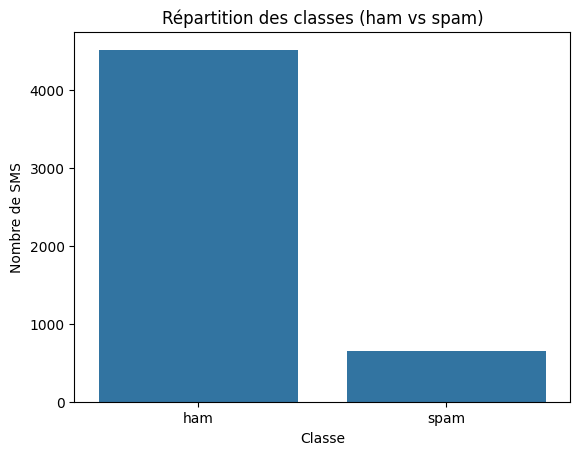

In [8]:
sns.countplot(data=df, x="label")
plt.title("Répartition des classes (ham vs spam)")
plt.xlabel("Classe")
plt.ylabel("Nombre de SMS")
plt.show()

On voit que les "ham" sont majoritaires (~87 %) face aux "spam" (~13 %) : le dataset est donc déséquilibré.

### 4. Longueur des messages

On vient comparer la longueur des messages "hame" et "spam".

In [9]:
df["length"] = df["message"].str.len()
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


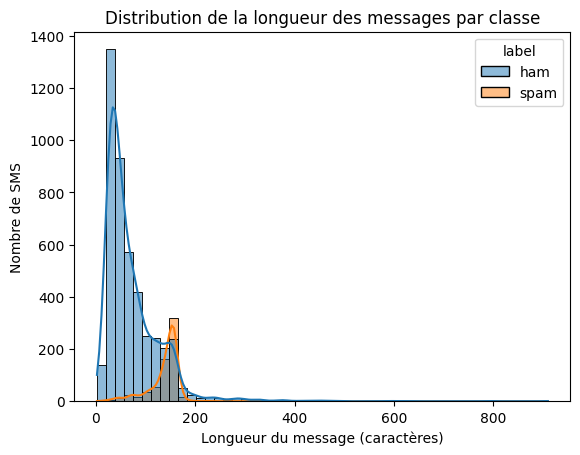

In [10]:
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Distribution de la longueur des messages par classe")
plt.xlabel("Longueur du message (caractères)")
plt.ylabel("Nombre de SMS")
plt.show()

On constate que les ham sont plus courts en moyenne que les spam.
La longueur des messages semble donc être un possible signal discriminant.

### 5. Extrait des données



In [11]:
print("Exemples de messages légitimes (HAM) :")
for msg in df[df["label"] == "ham"]["message"].head(3):
    print("-", msg)

print("\nExemples de messages de SPAM ===")
for msg in df[df["label"] == "spam"]["message"].head(3):
    print("-", msg)

Exemples de messages légitimes (HAM) :
- Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
- Ok lar... Joking wif u oni...
- U dun say so early hor... U c already then say...

Exemples de messages de SPAM ===
- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
- WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


## Nettoyage des données

En explorant les données, nous avons constaté la présence des textes / caractères spéciaux : URL, symboles, etc.

La fonction `clean_text` ci-dessous :
- garantit une chaîne de caractères (robustesse face aux types inattendus / `NaN`) ;
- normalise l'Unicode (`NFKC`) pour unifier les variantes équivalentes d'un même caractère ;
- retire les caractères de contrôle invisibles ;
- uniformise les espaces (tabulations, retours à la ligne, espaces multiples → un seul espace) ;
- supprime les espaces en début et fin.

On garde le texte original dans `message` et on écrit le résultat dans une nouvelle colonne `message_clean`, pour pouvoir comparer.

In [12]:
import re
import unicodedata

# On normalise d'abord les étiquettes (espaces parasites, casse) par sécurité
df["label"] = df["label"].str.strip().str.lower()
print("Étiquettes uniques après normalisation :", df["label"].unique())

def clean_text(text):
    """Nettoyage robuste d'un message SMS.

    On normalise la *structure* du texte (encodage, espaces, caractères de
    contrôle) SANS détruire les signaux utiles au classifieur (URLs, numéros,
    symboles monétaires £/$, MAJUSCULES...), souvent de bons indices de spam.
    """
    # 1. Garantir une chaîne (robustesse face aux NaN / types inattendus)
    if not isinstance(text, str):
        return ""
    # 2. Normalisation Unicode (NFKC) : unifie les variantes équivalentes d'un caractère
    text = unicodedata.normalize("NFKC", text)
    # 3. Suppression des caractères de contrôle invisibles (on garde l'espace)
    text = "".join(ch for ch in text if ch == " " or unicodedata.category(ch)[0] != "C")
    # 4. Uniformisation des espaces (tabs, retours ligne, espaces multiples -> 1 espace)
    text = re.sub(r"\s+", " ", text)
    # 5. Suppression des espaces en début / fin
    return text.strip()

# On conserve l'original dans "message" et on écrit le résultat dans "message_clean"
df["message_clean"] = df["message"].apply(clean_text)

df[["message", "message_clean"]].head(3)

Étiquettes uniques après normalisation : ['ham' 'spam']


,message,message_clean
0,"Go until jurong point, crazy.. Available only ...","Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...


On effectue deux contrôles après le nettoyage :
- certains messages peuvent devenir vides (s'ils ne contenaient que des caractères invisibles) : on les retire ;
- le nettoyage peut faire réapparaître des doublons (deux messages qui ne différaient que par des espaces ou des caractères de structure) → on déduplique à nouveau, cette fois sur le couple `(label, message_clean)`.

In [13]:
# Messages devenus vides après nettoyage (ne contenaient que des caractères invisibles)
n_vides = (df["message_clean"].str.len() == 0).sum()
print("Messages vides après nettoyage :", n_vides)

avant = len(df)
df = df[df["message_clean"].str.len() > 0]                         
# Le nettoyage peut faire réapparaître des doublons (messages identiques à des espaces près)
df = df.drop_duplicates(subset=["label", "message_clean"]).reset_index(drop=True)

print(f"Lignes retirées (vides + nouveaux doublons) : {avant - len(df)}")
print("Dimensions après nettoyage des données :", df.shape)

Messages vides après nettoyage : 0
Lignes retirées (vides + nouveaux doublons) : 11
Dimensions après nettoyage des données : (5158, 4)


## Détection des anomalies

Ici, on cherche les anomalies susceptibles de fausser l'apprentissage, en distinguant deux familles :
- les anomalies à corriger : le bruit dans les données (étiquettes contradictoires) ;
- les anomalies à conserver : les valeurs extrêmes qui sont en réalité du signal (un spam très long ou bourré de chiffres n'est pas une erreur, c'est un spam).

### 1. Étiquettes contradictoires

Un même texte annoté à la fois ham et spam est une contradiction d'annotation : le modèle recevrait des signaux opposés pour une entrée identique.

In [14]:
# Un même texte annoté à la fois "ham" ET "spam" envoie des signaux opposés au modèle
conflits = (
    df.groupby("message_clean")["label"]
      .nunique()
      .loc[lambda s: s > 1]
)
print("Nombre de messages aux étiquettes contradictoires :", len(conflits))
if len(conflits):
    display(
        df[df["message_clean"].isin(conflits.index)]
        .sort_values("message_clean")[["label", "message_clean"]]
        .head(10)
    )

Nombre de messages aux étiquettes contradictoires : 0


### 2. Longueurs aberrantes

On repère les longueurs extrèmes avec un écart interquartile.  
On considére comme aberrante toute valeur hors de l'intervalle [Q1 − 1,5·IQR ; Q3 + 1,5·IQR]. On calcule les bornes par classe.
En effet, un message long est normal pour un spam mais inhabituel pour un ham.

 ham : 138 longueurs aberrantes (hors [0 ; 176] caractères)
spam :  64 longueurs aberrantes (hors [92 ; 196] caractères)


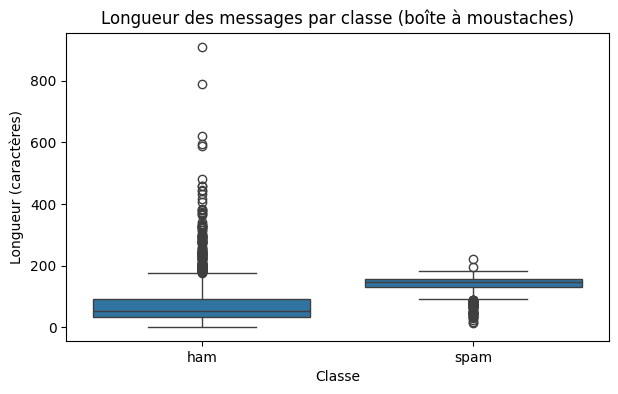

In [15]:
df["length"] = df["message_clean"].str.len()

def bornes_iqr(serie, k=1.5):
    """Bornes basse et haute selon la règle de l'écart interquartile."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Bornes calculées PAR CLASSE (un spam long n'est pas aberrant comme un ham long)
for cls in df["label"].unique():
    sub = df.loc[df["label"] == cls, "length"]
    bas, haut = bornes_iqr(sub)
    aberrants = sub[(sub < bas) | (sub > haut)]
    print(f"{cls:>4} : {len(aberrants):>3} longueurs aberrantes "
          f"(hors [{max(0, bas):.0f} ; {haut:.0f}] caractères)")

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="length")
plt.title("Longueur des messages par classe (boîte à moustaches)")
plt.xlabel("Classe")
plt.ylabel("Longueur (caractères)")
plt.show()

### 3. Composition des caractères

Le spam se distingue souvent par sa composition : beaucoup de chiffres (numéros, prix, codes), de majuscules (« WINNER!! ») ou de caractères non-ASCII ( ex: $, £, etc.).  
On quantifie ces proportions pour vérifier qu'elles séparent bien les deux classes.

In [16]:
def ratio(pattern, text):
    """Proportion de caractères correspondant au motif dans le texte."""
    if not text:
        return 0.0
    return len(re.findall(pattern, text)) / len(text)

df["ratio_chiffres"]   = df["message_clean"].apply(lambda t: ratio(r"\d", t))
df["ratio_majuscules"] = df["message_clean"].apply(lambda t: ratio(r"[A-Z]", t))
df["ratio_non_ascii"]  = df["message_clean"].apply(lambda t: ratio(r"[^\x00-\x7F]", t))

print("Composition moyenne des caractères par classe :")
display(df.groupby("label")[["ratio_chiffres", "ratio_majuscules", "ratio_non_ascii"]]
          .mean().round(3))

# Messages à composition extrême : plus de 50 % de chiffres ou de majuscules
suspects = df[(df["ratio_chiffres"] > 0.5) | (df["ratio_majuscules"] > 0.5)]
print(f"\nMessages à composition extrême (>50% chiffres ou majuscules) : {len(suspects)}")
display(suspects[["label", "message_clean", "ratio_chiffres", "ratio_majuscules"]].head(5))

Composition moyenne des caractères par classe :


,ratio_chiffres,ratio_majuscules,ratio_non_ascii
label,,,
ham,0.004,0.057,0.001
spam,0.115,0.110,0.003



Messages à composition extrême (>50% chiffres ou majuscules) : 112


,label,message_clean,ratio_chiffres,ratio_majuscules
14,ham,I HAVE A DATE ON SUNDAY WITH WILL!!,0.0,0.742857
43,ham,WHO ARE YOU SEEING?,0.0,0.789474
72,ham,HI BABE IM AT HOME NOW WANNA DO SOMETHING? XX,0.0,0.777778
128,ham,HEY GIRL. HOW R U? HOPE U R WELL ME AN DEL R B...,0.0,0.700935
238,ham,PLEASSSSSSSEEEEEE TEL ME V AVENT DONE SPORTSx,0.0,0.844444


Les seules anomalies réellement nettoyées sont les lignes vides et les doublons.  
En revanche, les longueurs extrêmes et les fortes proportions de chiffres/majuscules sont conservées : ce ne sont pas des erreurs mais des caractéristiques discriminantes du spam, que le modèle doit apprendre à reconnaître.

## Augmentation de données

Nous avons vu dans l'EDA que les données sont fortement déséquilibrées, nous alons procéder à une augementation des données.

Nous allons procédé à :
- un random swap : on échange deux mots au hasard ;
- une random deletion : on supprime chaque mot avec une faible probabilité.

Ces transformations conservent le sens global du message tout en produisant des exemples légèrement différents.

In [17]:
import random

random.seed(42)  # reproductibilité

def random_swap(words, n=1):
    """Échange n fois deux mots tirés au hasard."""
    words = words.copy()
    for _ in range(n):
        if len(words) < 2:
            break
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return words

def random_deletion(words, p=0.1):
    """Supprime chaque mot avec une probabilité p (en gardant au moins un mot)."""
    if len(words) <= 1:
        return words
    kept = [w for w in words if random.random() > p]
    return kept if kept else [random.choice(words)]

def augment(text, n=1, p=0.1):
    """Crée une variante d'un message : échange de mots puis suppression aléatoire."""
    words = text.split()
    words = random_swap(words, n=n)
    words = random_deletion(words, p=p)
    return " ".join(words)

# Démonstration sur un message de spam
exemple = df[df["label"] == "spam"]["message_clean"].iloc[0]
print("Original :", exemple)
print("Variante :", augment(exemple, n=2, p=0.1))

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Variante : question(std entry in to a comp win FA final tkts 21st May 2005. Text to 87121 2 receive entry Free apply 08452810075over18's


On découpe donc d'abord (avec `stratify` pour conserver les proportions), puis on augmente seulement la classe minoritaire (`spam`) du jeu d'entraînement pour le rééquilibrer.

In [18]:
from sklearn.model_selection import train_test_split

X = df["message_clean"]
y = df["label"]

# Découpage AVANT augmentation, avec stratification pour préserver les proportions ham/spam
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Avant augmentation (train) :")
print(y_train.value_counts())

# Augmentation UNIQUEMENT du train et UNIQUEMENT de la classe minoritaire (spam)
train = pd.DataFrame({"message": X_train.values, "label": y_train.values})
spam_train = train[train["label"] == "spam"]["message"].reset_index(drop=True)
n_manquant = (y_train == "ham").sum() - (y_train == "spam").sum()

augmentes = [
    {"message": augment(spam_train.iloc[i % len(spam_train)], n=2, p=0.1), "label": "spam"}
    for i in range(n_manquant)
]
train_augmente = pd.concat([train, pd.DataFrame(augmentes)], ignore_index=True)

print(f"\n{n_manquant} spams synthétiques ajoutés.")
print("\nAprès augmentation (train rééquilibré) :")
print(train_augmente["label"].value_counts())
print("\nLe jeu de test reste intact :", len(X_test), "messages.")

Avant augmentation (train) :
label
ham     3612
spam     514
Name: count, dtype: int64

3098 spams synthétiques ajoutés.

Après augmentation (train rééquilibré) :
label
ham     3612
spam    3612
Name: count, dtype: int64

Le jeu de test reste intact : 1032 messages.


## Machine learning

### Pourquoi ElasticNet ?

La régularisation ajoute à la fonction de coût une pénalité sur la taille des coefficients, pour limiter le sur-apprentissage.  
Les trois formes classiques se retrouvent dans la régression via le paramètre `penalty` :

| Forme (régression) | Pénalité | `LogisticRegression` | Effet |
|---|---|---|---|
| Ridge | **L2** (somme des carrés) | `penalty='l2'` | rétrécit les coefficients, **les garde tous** |
| Lasso | **L1** (somme des valeurs absolues) | `penalty='l1'` | **annule** des coefficients → parcimonie / sélection |
| ElasticNet | **L1 + L2** | `penalty='elasticnet'` | combine sélection **et** stabilité |

Choix retenu : ElasticNet, parce qu'il colle au profil de nos données :
1. le TF-IDF est très haute dimension et creux (des milliers de termes, en majorité inutiles) → la part L1 fait une sélection de variables automatique et rend le modèle interprétable ;
2. les mots du spam sont corrélés (free / win / prize / claim co-apparaissent) : le Lasso pur en choisit un au hasard et devient instable → la part L2 stabilise ces groupes ;
3. ElasticNet réunit donc les avantages de Ridge et de Lasso qsdsqs— le meilleur compromis pour du texte.

### 1. Vectorisation TF-IDF

Un modèle ML ne traite pas du texte brut : il faut le transformer en vecteurs numériques. On utilise TF-IDF (Term Frequency – Inverse Document Frequency), qui pondère chaque terme par sa fréquence dans le message et sa rareté dans l'ensemble du corpus — les mots très communs (« the », « to ») pèsent peu, les mots discriminants pèsent davantage.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Données issues du découpage précédent.
# Train AUGMENTÉ et rééquilibré ; test intact (jamais augmenté) -> évaluation honnête.
X_train_txt = train_augmente["message"]
y_train_bl  = train_augmente["label"]
# X_test, y_test proviennent déjà du split stratifié réalisé plus haut.

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),   # unigrammes + bigrammes ("free entry", "txt rate"...)
    min_df=2,             # ignore les termes présents dans < 2 messages (bruit)
    sublinear_tf=True,    # 1 + log(tf) : atténue le poids des répétitions
)

# fit_transform sur le train, transform seul sur le test -> aucune fuite de vocabulaire
X_train_vec = vectorizer.fit_transform(X_train_txt)
X_test_vec  = vectorizer.transform(X_test)

print("Matrice train :", X_train_vec.shape)
print("Matrice test  :", X_test_vec.shape)
print(f"Vocabulaire   : {len(vectorizer.vocabulary_)} termes")

Matrice train : (7224, 18483)
Matrice test  : (1032, 18483)
Vocabulaire   : 18483 termes


### 2. Entraînement de la baseline et choix des métriques

On entraîne une régression logistique régularisée en ElasticNet sur le train (vectorisé et rééquilibré) et on l'évalue sur le test intact.

Choix des métriques. Le test reste déséquilibré (~87 % ham). L'accuracy y est trompeuse : un modèle qui prédit toujours « ham » obtiendrait déjà ~87 %. On privilégie donc :
- la précision (parmi les messages classés spam, combien le sont vraiment → éviter de bloquer un vrai message),
- le rappel (parmi les vrais spams, combien sont détectés),
- le F1, leur moyenne harmonique, et la matrice de confusion pour visualiser les erreurs.

Rapport de classification (jeu de test)
              precision    recall  f1-score   support

         ham      0.990     0.966     0.978       904
        spam      0.793     0.930     0.856       128

    accuracy                          0.961      1032
   macro avg      0.892     0.948     0.917      1032
weighted avg      0.965     0.961     0.963      1032



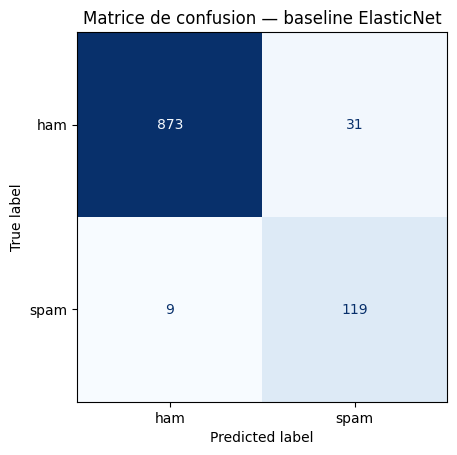

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

# Baseline : régression logistique régularisée ElasticNet (mélange L1 + L2)
#   - L1 -> parcimonie : met à 0 les mots non informatifs (sélection de variables)
#   - L2 -> stabilité  : gère les groupes de mots corrélés (free / win / prize ...)
# solver='saga' : le seul de sklearn qui supporte la pénalité 'elasticnet'.
baseline = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,      # 50 % L1 / 50 % L2
    C=1.0,             # inverse de la force de régularisation
    max_iter=2000,
    random_state=42,
)
baseline.fit(X_train_vec, y_train_bl)

y_pred = baseline.predict(X_test_vec)

print("Rapport de classification (jeu de test)")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues", colorbar=False)
plt.title("Matrice de confusion — baseline ElasticNet")
plt.show()

### 3. Démonstration de l'effet de la régularisation

On compare donc plusieurs réglages en faisant varier les deux leviers d'ElasticNet:
- **`l1_ratio`** : le dosage entre L1 et L2. `0.0` = **Ridge pur** (L2), `1.0` = **Lasso pur** (L1), entre les deux = **ElasticNet** ;
- **`C`** : l'inverse de la force de régularisation. Un `C` **petit** régularise **fort** (coefficients tirés vers 0).

In [21]:
# On illustre les DEUX leviers de la régularisation :
#   - l1_ratio : dosage L1 vs L2  (0 = Ridge pur, 1 = Lasso pur, entre les deux = ElasticNet)
#   - C        : force globale    (C petit = régularisation forte = davantage de coefs à 0)
resultats = []
for C in [0.1, 1.0, 10.0]:
    for l1_ratio in [0.0, 0.5, 1.0]:
        m = LogisticRegression(penalty="elasticnet", solver="saga",
                               l1_ratio=l1_ratio, C=C, max_iter=2000, random_state=42)
        m.fit(X_train_vec, y_train_bl)
        coefs = m.coef_.ravel()
        nnz = int((coefs != 0).sum())
        f1 = f1_score(y_test, m.predict(X_test_vec), pos_label="spam")
        resultats.append({
            "type": {0.0: "Ridge (L2)", 1.0: "Lasso (L1)"}.get(l1_ratio, "ElasticNet"),
            "C": C,
            "l1_ratio": l1_ratio,
            "coefs_non_nuls": nnz,
            "part_nulle_%": round(100 * (1 - nnz / len(coefs)), 1),
            "F1_spam": round(f1, 3),
        })

tab = pd.DataFrame(resultats)
display(tab.sort_values(["C", "l1_ratio"]).reset_index(drop=True))

c:\Users\G713\repos\IPSSI\deep_learning\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,type,C,l1_ratio,coefs_non_nuls,part_nulle_%,F1_spam
0,Ridge (L2),0.1,0.0,18483,0.0,0.850
1,ElasticNet,0.1,0.5,154,99.2,0.760
2,Lasso (L1),0.1,1.0,28,99.8,0.710
3,Ridge (L2),1.0,0.0,18483,0.0,0.906
4,ElasticNet,1.0,0.5,1322,92.8,0.856
5,Lasso (L1),1.0,1.0,231,98.8,0.858
6,Ridge (L2),10.0,0.0,18483,0.0,0.919
7,ElasticNet,10.0,0.5,4434,76.0,0.921
8,Lasso (L1),10.0,1.0,590,96.8,0.904


Lecture du tableau :   
- plus la part L1 est forte, plus le modèle est parcimonieux (beaucoup de mots mis à zéro). Le Ridge pur (`l1_ratio=0`) garde au contraire tous les coefficients.
- Le F1 reste élevé même avec beaucoup de zéros : on peut donc supprimer une grande partie des features sans perdre en performance

### 4. Interprétation

Dans un modèle linéaire régularisé : chaque mot possède un coefficient. Les plus positifs tirent vers la classe positive (spam), les plus négatifs vers ham.

In [22]:
import numpy as np

# Coefficients de la baseline ElasticNet (l1_ratio=0.5, C=1).
# En binaire, coef_ correspond à la classe positive = classes_[1].
features = np.array(vectorizer.get_feature_names_out())
coefs = baseline.coef_.ravel()
ordre = np.argsort(coefs)

print("Classe positive (coef > 0) :", baseline.classes_[1])
print(f"Termes retenus (coef != 0) : {(coefs != 0).sum()} / {len(coefs)}")

print("\n--- 15 termes les plus prédictifs de SPAM ---")
for i in ordre[::-1][:15]:
    print(f"  {features[i]:<22} {coefs[i]:+.3f}")

print("\n--- 15 termes les plus prédictifs de HAM ---")
for i in ordre[:15]:
    print(f"  {features[i]:<22} {coefs[i]:+.3f}")

Classe positive (coef > 0) : spam
Termes retenus (coef != 0) : 1322 / 18483

--- 15 termes les plus prédictifs de SPAM ---
  call                   +10.660
  txt                    +7.991
  text                   +7.233
  free                   +6.107
  stop                   +5.536
  150p                   +5.480
  claim                  +5.460
  reply                  +5.293
  www                    +5.116
  uk                     +5.093
  mobile                 +5.088
  50                     +4.825
  to                     +4.747
  chat                   +4.712
  service                +4.708

--- 15 termes les plus prédictifs de HAM ---
  my                     -5.997
  me                     -5.120
  that                   -3.909
  ok                     -3.862
  but                    -3.465
  it                     -3.358
  da                     -3.274
  he                     -3.193
  how                    -3.139
  then                   -3.116
  gt                     -3.00

### Bilan de l'approche machine learning

L'utilisation d'ElasticNet atteint déjà de très bons scores, ce qui en fait une référence à battre pour le modèle de deep learning (RNN) à venir.

## Visualisation de synthèse

Pour clôturer l'approche ML, on récapitule visuellement deux choses :
- ce que le modèle a appris → les coefficients les plus discriminants ;
- à quel point il performe → les courbes ROC et précision-rappel.

Ces figures réutilisent les objets déjà entraînés plus haut (`baseline`, `vectorizer`) : aucune nouvelle étape de modélisation n'est introduite.

### 1. Termes les plus discriminants

Version graphique de l'interprétation précédente : on affiche côte à côte les 15 coefficients les plus négatifs (signaux de ham, en bleu) et les 15 plus positifs (signaux de **spam**, en rouge).

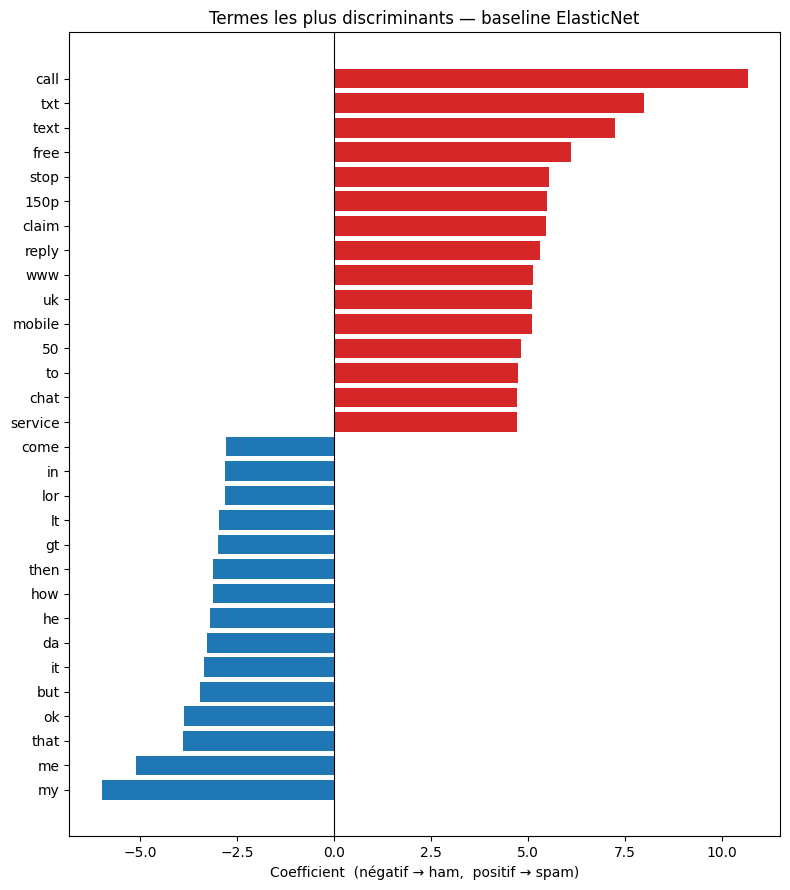

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Coefficients de la baseline ElasticNet ; classe positive = spam
features = np.array(vectorizer.get_feature_names_out())
coefs    = baseline.coef_.ravel()
ordre    = np.argsort(coefs)

k = 15
# k coefficients les plus négatifs (ham) + k les plus positifs (spam), triés par valeur
idx = np.concatenate([ordre[:k], ordre[-k:]])
idx = idx[np.argsort(coefs[idx])]

noms     = features[idx]
valeurs  = coefs[idx]
couleurs = ["#d62728" if v > 0 else "#1f77b4" for v in valeurs]  # rouge = spam, bleu = ham

plt.figure(figsize=(8, 9))
plt.barh(range(len(idx)), valeurs, color=couleurs)
plt.yticks(range(len(idx)), noms)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient  (négatif → ham,  positif → spam)")
plt.title("Termes les plus discriminants — baseline ElasticNet")
plt.tight_layout()
plt.show()

### 2. Courbes ROC et précision-rappel

Pour la courbe précision-rappel : sa ligne de hasard correspond à la proportion de spam, et la précision moyenne (AP) résume la qualité du classement. L'AUC de la ROC mesure quant à elle la capacité du modèle à ranger un spam avant un ham.

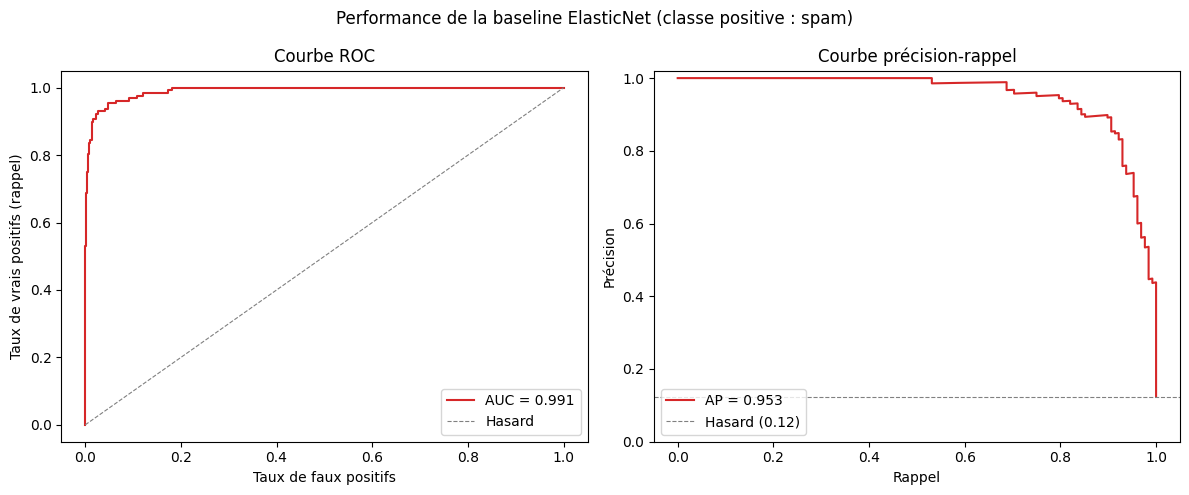

In [24]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score)

# Score de la classe positive (spam) pour chaque message du test
spam_idx   = list(baseline.classes_).index("spam")
y_score    = baseline.predict_proba(X_test_vec)[:, spam_idx]
y_true_bin = (y_test == "spam").astype(int)

fpr, tpr, _   = roc_curve(y_true_bin, y_score)
roc_auc       = auc(fpr, tpr)
prec, rec, _  = precision_recall_curve(y_true_bin, y_score)
ap            = average_precision_score(y_true_bin, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC ---
axes[0].plot(fpr, tpr, color="#d62728", label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=0.8, label="Hasard")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title("Courbe ROC")
axes[0].legend(loc="lower right")

# --- Précision-rappel ---
axes[1].plot(rec, prec, color="#d62728", label=f"AP = {ap:.3f}")
axes[1].axhline(y_true_bin.mean(), ls="--", color="grey", linewidth=0.8,
                label=f"Hasard ({y_true_bin.mean():.2f})")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe précision-rappel")
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower left")

plt.suptitle("Performance de la baseline ElasticNet (classe positive : spam)")
plt.tight_layout()
plt.show()

# Deep Learning

Après le machine learning, nous allons passer au deep learning.  
Avant de procéder à la mise en place du réseau de neurones, il nous faut choisir le type de réseau le plus adapté à nos données. L

Nos données sont des SMS, c'est-à-dire de courtes suites de mots où l'ordre a du sens. Le MLP n'est pas opportun car il ne tient pas compte de cet ordre.   Le CNN, quant à lui, ne voit que des morceaux courts.   
Le RNN, lui, traite le message en séquence et garde en mémoire le contexte des mots précédents.

Nous allons donc partir sur le RNN. 

## Recherche des hyperparamètres pertinents

Avant de procéder à l'entrainement du réseau nous avons procédés aux choix suivants :

### Le choix de l'optimiseur

Nous avons opté pour Adam optimiseur car il ajuste tout seul la vitesse d'apprentissage et reste stable sur la majorité des problèmes.

### Le problème du vanishing / exploding gradient

#### Les fonctions d'activation

Les fonctions d'activation décident de ce que chaque neurone transmet. Certaines peuvent aggraver le vanishing gradient.

Nous alons donc privilégier :
- ReLU pour les couches denses, car elle laisse passer le signal sans l'écraser
- une cellule de type LSTM pour la partie récurrente. Ces cellules protègeront le gradient sur de longues séquences.

#### La normalisation

Concernant la normalisation, nous utiliserons une Layer Normalization qui est bien plus stable que la Batch Normalization pour un RNN.

#### Le gradient clipping

Enfin, pour éviter l'exploding gradient, nous allons limiter la taille du gradient (gradient clipping) : dès qu'il dépasse un seuil, on le ramène à une valeur maximale.


### Mise en pratique

Nous avons fait le choix d'utiliser un modèle Keras avec TensorFlow.  
On va commencer  par transformer chaque message en une suite d'entiers (un identifiant par mot), puis uniformiser la longueur des messages. On réutilise le découpage train / test réalisé en amont.

In [25]:
from tensorflow.keras.layers import TextVectorization

# Le RNN lit des suites d'entiers : on convertit chaque mot en un identifiant.
num_mots = 10000   # on ne garde que les 10 000 mots les plus fréquents
max_len  = 50      # toutes les séquences seront ramenées à 50 mots (padding / troncature)

vectoriseur = TextVectorization(
    max_tokens=num_mots,
    output_mode="int",
    output_sequence_length=max_len,
)
# Le vocabulaire est appris sur le TRAIN uniquement -> aucune fuite vers le test
vectoriseur.adapt(X_train_txt.values)

X_train_seq = vectoriseur(X_train_txt.values)
X_test_seq  = vectoriseur(X_test.values)

# Étiquettes en 0 / 1 (spam = 1)
y_train_rnn = (y_train_bl == "spam").astype("int32").values
y_test_rnn  = (y_test == "spam").astype("int32").values

vocab_size = vectoriseur.vocabulary_size()
print("Forme train :", X_train_seq.shape, " | test :", X_test_seq.shape)
print("Taille du vocabulaire :", vocab_size)

Forme train : (7224, 50)  | test : (1032, 50)
Taille du vocabulaire : 8440


In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, LSTM,
                                      LayerNormalization, Dense, Dropout)
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)  # reproductibilité

model = Sequential([
    Input(shape=(max_len,)),

    # Embedding : transforme chaque identifiant de mot en un petit vecteur appris
    Embedding(input_dim=vocab_size, output_dim=64),

    # LSTM : cellule récurrente à portes -> protège le gradient sur la séquence
    # (réponse directe au vanishing gradient)
    LSTM(64),

    # Layer Normalization : remet les valeurs à une échelle stable
    LayerNormalization(),

    # Couche dense avec ReLU : laisse passer le signal sans l'écraser
    Dense(32, activation="relu"),
    Dropout(0.3),

    # Sortie : 1 neurone sigmoïde -> probabilité d'être un spam
    Dense(1, activation="sigmoid"),
])

# Optimiseur Adam + gradient clipping (clipnorm) contre l'exploding gradient
optimiseur = Adam(learning_rate=1e-3, clipnorm=1.0)

model.compile(
    optimizer=optimiseur,
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       540,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,425 (2.20 MB)

 Trainable params: 575,425 (2.20 MB)

 Non-trainable params: 0 (0.00 B)